# Notebook 01b - Spline Choreography Kinematics, Jerk-Minimised (QP)

Author: Stellars Henson<br>
Approach: model the full 3 s choreography as a **single C2-continuous trajectory** for one body - Victoria's centre of mass - with position, velocity and acceleration all smooth.  The tangential acceleration along the path is a **cubic spline**; velocity and position are its analytic antiderivatives, so the position trajectory is C4.  The spline knots are placed by **quadratic programming**: minimise the integrated jerk-squared subject to *linear* constraints.

## Model decisions

- **One body only.**  This is a kinematics study of Victoria's CoM.  Andrew's motion is not modelled here.
- **Stationary points at the direction changes.**  At the impact moment (the change of direction at the door) both velocity AND acceleration are effectively zero - the body decelerates to a momentary rest at the door, then reverses.  Likewise the choreography starts and ends at rest.  So there are three stationary points: start (t=0), impact (t=t_impact), end (t=3), each with v=0 and a=0.
- **Pull distance 2.0 m** - the curved-path arc length (corridor diagonal + the body rotation mean the CoM cannot travel a straight line).
- **Forces are computed later, not here.**  The total force at the impact will be the sum of an *impact force* (the collision / body compression) plus an *acceleration force* (Victoria pushing herself off the door and driving with her feet).  Their proportion is a kinematics hyperparameter applied downstream.  This notebook produces only the smooth kinematic trajectory; `a(t)` here is the net kinematic acceleration.

## Outputs

- `reports/figures/01b-path-curve.png` - the curved CoM path in the corridor plane
- `reports/figures/01b-trajectory-splines.png` - position / velocity / acceleration / jerk, all smooth
- `reports/figures/01b-continuity-check.png` - numerical C2 continuity verification
- `reports/figures/01b-yield-study.png` - peak impact force vs body compressive-yield model

In [1]:
# Imports
from __future__ import annotations

import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rich.console import Console
from rich.panel import Panel
from rich.table import Table

from scipy.interpolate import CubicSpline

%load_ext autoreload
%autoreload 2

console = Console()
sns.set_theme(style="whitegrid", context="notebook")

In [2]:
SEED = 42
np.random.seed(SEED)

## Kinematics Linear Prototype

Before the smooth spline trajectory, the problem is grounded with the **kinematics linear prototype** - a piecewise-linear acceleration model, the idealised skeleton that the later spline smoothing, integration and QP optimisation refine.  In this reference model the acceleration is a sequence of straight-line ramps and plateaus; integrating once gives a piecewise-quadratic velocity and again a piecewise-cubic position.  The diagram below shows all three.  It is **symbolic** - the impact spike `a_imp` is physically about ten times deeper than `a_max`, so it is drawn off-scale on the acceleration panel to keep the choreography levels visible.  The segment areas are balanced, so velocity returns to zero at the start, at the foot of the impact spike, and at the end.

**Phase 1** (pull to the door):

1. **Start jerk / give** - acceleration ramps linearly from `a = 0` up to `a_max`
2. **Constant acceleration** - plateau at `a_max`
3. **Release** - acceleration ramps `a_max -> 0` over its yield time
4. **Coast** - `a = 0`, the body travels at constant speed
5. **Impact** - a deceleration spike `0 -> a_imp -> 0`, ending when `v = 0`; this spike is the **decoupled singularity**, resolved separately on its own millisecond timeline

**Phase 2** (return from the door):

1. **Reverse jerk** - acceleration ramps from `(a = 0, v = 0)` to the reverse-direction acceleration `a_rev`
2. **Deceleration** - acceleration ramps from `a_rev` through zero to the brake level `a_brk`, then back to `0`, bringing the body to rest (`a = 0, v = 0`)

The ramp corners in this model are sharp - infinite jerk at every breakpoint.  The spline model below replaces each corner with a C2-smooth transition, and the QP places the knots to minimise jerk.  The linear model is the reference the smoothed trajectory is measured against.

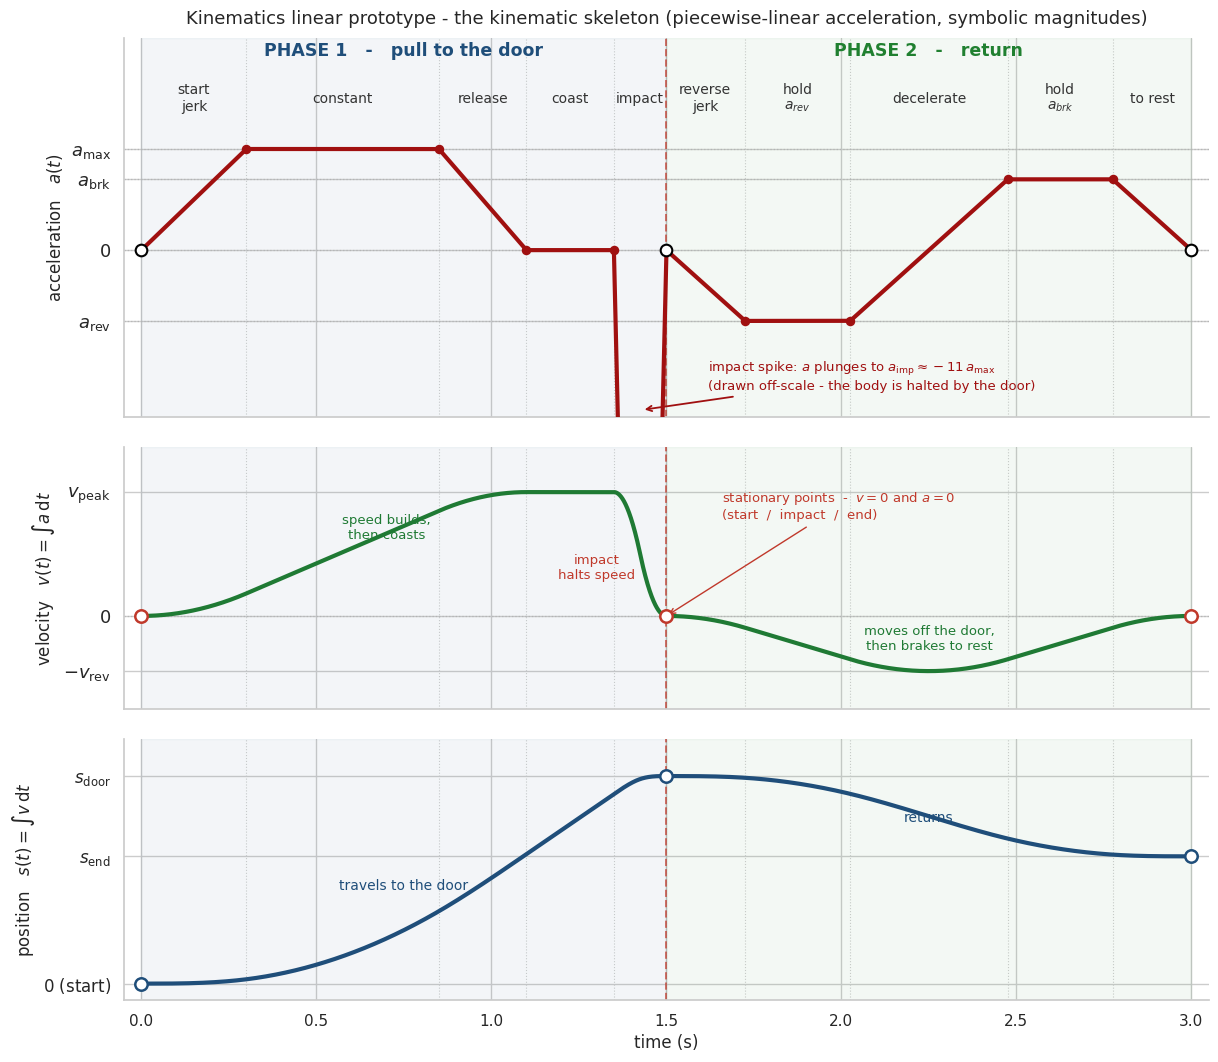

Linear reference model: acceleration (piecewise-linear) integrates to velocity (piecewise-quadratic) and to position (piecewise-cubic). Vertical guides link the same instant across all three panels. Areas balanced so v=0 at the three stationary points. The sharp corners are infinite-jerk - the spline QP below smooths them to C2.


In [3]:
# Linear reference model - piecewise-linear acceleration, SYMBOLIC schematic.
# Areas balanced so velocity returns to zero at every stationary point
# (start, impact, end). Acceleration integrates once to velocity, again to
# position. The impact spike a_imp is ~11x deeper than a_max and is drawn
# off-scale so the choreography levels stay legible. Structure only.
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from pathlib import Path as _Path
_FIG_DIR = _Path("..") / "reports" / "figures"
_FIG_DIR.mkdir(parents=True, exist_ok=True)

# symbolic acceleration levels (illustrative magnitudes)
a_max = 1.00                     # phase-1 peak choreography acceleration
a_rev = -0.70                    # phase-2 reverse-direction acceleration
a_brk = -a_rev                   # phase-2 brake (mirrors a_rev -> phase-2 v balances)

# piecewise-linear acceleration breakpoints (time, accel)
bp_t = [0.00, 0.30, 0.85, 1.10, 1.35, 1.425, 1.50,
        1.725, 2.025, 2.475, 2.775, 3.00]
A_accel = 0.5 * 0.30 * a_max + 0.55 * a_max + 0.5 * 0.25 * a_max
a_imp = -A_accel / (0.5 * 0.15)   # impact depth that cancels the phase-1 accel area
bp_a = [0.0, a_max, a_max, 0.0, 0.0, a_imp, 0.0,
        a_rev, a_rev, a_brk, a_brk, 0.0]

# integrate: a -> v -> s
tg = np.linspace(0, 3.0, 6000)
a_lin = np.interp(tg, bp_t, bp_a)
v_lin = np.concatenate([[0], np.cumsum((a_lin[1:] + a_lin[:-1]) / 2 * np.diff(tg))])
s_lin = np.concatenate([[0], np.cumsum((v_lin[1:] + v_lin[:-1]) / 2 * np.diff(tg))])
t_imp = 1.5
v_imp, s_imp = np.interp(t_imp, tg, v_lin), np.interp(t_imp, tg, s_lin)
v_peak, v_min, s_end = v_lin.max(), v_lin.min(), s_lin[-1]

# segment dividers + labels
seg_bounds = [0.30, 0.85, 1.10, 1.35, 1.50, 1.725, 2.025, 2.475, 2.775]
segments = [(0.15, "start\njerk"), (0.575, "constant"), (0.975, "release"),
            (1.225, "coast"), (1.425, "impact"), (1.61, "reverse\njerk"),
            (1.875, "hold\n$a_{rev}$"), (2.25, "decelerate"),
            (2.625, "hold\n$a_{brk}$"), (2.89, "to rest")]

fig = plt.figure(figsize=(14, 12.5))
gs = GridSpec(3, 1, height_ratios=[1.45, 1.0, 1.0], hspace=0.10)
ax_a = fig.add_subplot(gs[0])
ax_v = fig.add_subplot(gs[1], sharex=ax_a)
ax_s = fig.add_subplot(gs[2], sharex=ax_a)

# shared backdrop: phase tints + segment dividers + impact line
for ax in (ax_a, ax_v, ax_s):
    ax.axvspan(0.0, 1.5, color="#1f4e7a", alpha=0.05)
    ax.axvspan(1.5, 3.0, color="#208030", alpha=0.05)
    for xb in seg_bounds:
        ax.axvline(xb, color="#cfcfcf", ls=":", lw=0.8, zorder=0)
    ax.axvline(1.5, color="#c0392b", ls="--", lw=1.4, alpha=0.7, zorder=1)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlim(-0.05, 3.05)

# ----- ACCELERATION -----
for lvl in (a_max, a_brk, 0.0, a_rev):
    ax_a.axhline(lvl, color="#b0b0b0", ls=":", lw=0.9, alpha=0.8)
ax_a.plot(tg, a_lin, color="#a01010", lw=3.0, solid_joinstyle="round", zorder=4)
ax_a.scatter(bp_t, bp_a, color="#a01010", s=34, zorder=5)   # knots
ax_a.scatter([0, 1.5, 3.0], [0, 0, 0], facecolor="white", edgecolor="black",
             s=70, lw=1.5, zorder=6)
ax_a.set_yticks([a_rev, 0.0, a_brk, a_max])
ax_a.set_yticklabels([r"$a_\mathrm{rev}$", "$0$", r"$a_\mathrm{brk}$",
                      r"$a_\mathrm{max}$"], fontsize=13)
ax_a.set_ylim(a_rev - 0.95, a_max * 2.10)
ax_a.set_ylabel("acceleration   $a(t)$", fontsize=12)
# segment labels in a band above the curve
for tx, lab in segments:
    ax_a.text(tx, a_max * 1.50, lab, ha="center", va="center", fontsize=10,
              color="#333333")
# phase headers
ax_a.text(0.75, a_max * 1.92, "PHASE 1   -   pull to the door", ha="center",
          fontsize=12.5, fontweight="bold", color="#1f4e7a")
ax_a.text(2.25, a_max * 1.92, "PHASE 2   -   return", ha="center",
          fontsize=12.5, fontweight="bold", color="#208030")
# impact off-scale callout
ax_a.annotate(r"impact spike: $a$ plunges to $a_\mathrm{imp}\approx-11\,a_\mathrm{max}$"
              "\n(drawn off-scale - the body is halted by the door)",
              xy=(1.43, a_rev - 0.88), xytext=(1.62, a_rev - 0.55),
              fontsize=9.5, color="#a01010", va="center",
              arrowprops=dict(arrowstyle="->", color="#a01010", lw=1.3))
ax_a.set_title("Kinematics linear prototype - the kinematic skeleton "
               "(piecewise-linear acceleration, symbolic magnitudes)",
               fontsize=13, pad=10)

# ----- VELOCITY -----
ax_v.axhline(0.0, color="#b0b0b0", ls=":", lw=0.9, alpha=0.8)
ax_v.plot(tg, v_lin, color="#1f7a34", lw=3.0, zorder=4)
ax_v.scatter([0, t_imp, 3.0], [0, v_imp, 0], facecolor="white",
             edgecolor="#c0392b", s=80, lw=1.8, zorder=6)
ax_v.set_yticks([v_min, 0.0, v_peak])
ax_v.set_yticklabels([r"$-v_\mathrm{rev}$", "$0$", r"$v_\mathrm{peak}$"],
                     fontsize=13)
ax_v.set_ylabel(r"velocity   $v(t)=\int a\,\mathrm{d}t$", fontsize=12)
ax_v.set_ylim(v_min - 0.25, v_peak + 0.30)
ax_v.text(0.70, v_peak * 0.62, "speed builds,\nthen coasts", ha="center",
          fontsize=9.5, color="#1f7a34")
ax_v.text(1.30, v_peak * 0.30, "impact\nhalts speed", ha="center", fontsize=9.5,
          color="#c0392b")
ax_v.text(2.25, v_min * 0.62, "moves off the door,\nthen brakes to rest",
          ha="center", fontsize=9.5, color="#1f7a34")
ax_v.annotate("stationary points  -  $v=0$ and $a=0$\n(start  /  impact  /  end)",
              xy=(t_imp, v_imp), xytext=(1.66, v_peak * 0.78), fontsize=9.5,
              color="#c0392b", arrowprops=dict(arrowstyle="->", color="#c0392b"))

# ----- POSITION -----
ax_s.plot(tg, s_lin, color="#1f4e7a", lw=3.0, zorder=4)
ax_s.scatter([0, t_imp, 3.0], [0, s_imp, s_end], facecolor="white",
             edgecolor="#1f4e7a", s=80, lw=1.8, zorder=6)
ax_s.set_yticks([0.0, s_end, s_imp])
ax_s.set_yticklabels(["$0$ (start)", r"$s_\mathrm{end}$", r"$s_\mathrm{door}$"],
                     fontsize=12)
ax_s.set_ylabel(r"position   $s(t)=\int v\,\mathrm{d}t$", fontsize=12)
ax_s.set_ylim(-0.08 * s_imp, s_imp * 1.18)
ax_s.set_xlabel("time (s)", fontsize=12)
ax_s.text(0.75, s_imp * 0.45, "travels to the door", ha="center", fontsize=10,
          color="#1f4e7a")
ax_s.text(2.25, s_imp * 0.78, "returns", ha="center", fontsize=10,
          color="#1f4e7a")

for ax in (ax_a, ax_v):
    plt.setp(ax.get_xticklabels(), visible=False)

fig.savefig(_FIG_DIR / "01b-linear-reference-model.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("Linear reference model: acceleration (piecewise-linear) integrates to "
      "velocity (piecewise-quadratic) and to position (piecewise-cubic). "
      "Vertical guides link the same instant across all three panels. Areas "
      "balanced so v=0 at the three stationary points. The sharp corners are "
      "infinite-jerk - the spline QP below smooths them to C2.")

### Prototype variables - inputs and outputs

The kinematics linear prototype names every variable the model works with and fixes the role each one plays. There are four kinds:

- **Hyperparameter** - a value the analyst sets; the model takes it as given
- **Boundary condition** - a value pinned at a phase boundary; these become the equality constraints each phase QP must satisfy
- **Optimisation result** - a value a phase QP produces; emergent from minimising jerk under the constraints
- **Singularity output** - a value the decoupled impact model returns, computed from the closing velocity on its own millisecond timeline

| Symbol | Quantity | Role | Value / origin |
|---|---|---|---|
| $T$ | total choreography time | hyperparameter | 3.0 s, fixed at the claim |
| $t_1$ | phase-1 duration (phase split) | hyperparameter | 1.5 s, configurable |
| $L_\text{arc}$ | phase-1 curved-path length | hyperparameter | 2.0 m, corridor geometry |
| $\Delta s_2$ | phase-2 return translation | hyperparameter | 0.50 m |
| $d,\;k$ | body compression, stiffness | hyperparameter | 3 cm, $8\times10^5$ N/m (rigid door, FEA body) |
| $a(0),\,v(0),\,s(0)$ | phase-1 start | boundary condition | all $0$ - at rest at the origin |
| $a(t_1)$ | phase-1 end (contact) | boundary condition | $0$ - released, coasting into the door |
| $s(t_1)$ | position at contact | boundary condition | $=L_\text{arc}$ |
| $v,\,a$ at phase-2 start | post-singularity rest | boundary condition | both $0$ - body at rest after the impact |
| $v(T),\,a(T)$ | phase-2 end | boundary condition | both $0$ - at rest |
| $s(T)$ | final position | boundary condition | $=L_\text{arc}-\Delta s_2$ |
| $\mathbf{a}_1,\,\mathbf{a}_2$ | per-phase spline knot vectors | optimisation result | the QP decision variables |
| $v_\text{close}$ | closing velocity at contact | optimisation result | emergent - phase-1 terminal velocity, left free in the QP |
| $a_\text{max}$ | phase-1 peak acceleration | optimisation result | emergent |
| $v_\text{rev}$ | phase-2 peak return speed | optimisation result | emergent |
| $a_\text{rev},\,a_\text{brk}$ | phase-2 accel / brake peaks | optimisation result | emergent |
| $j_\text{peak}$ | peak jerk, per phase | optimisation result | emergent |
| $a_\text{imp}$ | impact peak deceleration | singularity output | from $v_\text{close}$, $d$, yield model |
| $\tau_\text{imp}$ | impact duration | singularity output | $\approx 2d/v_\text{close}$, a few tens of ms |
| $F_\text{imp}$ | impact force | singularity output | $m\,a_\text{imp}$ |

Each phase QP takes the hyperparameters and boundary conditions and returns the optimisation results. The closing velocity $v_\text{close}$ is then handed to the decoupled impact singularity, which returns its own outputs on a separate millisecond timeline.

The permissible literature bands for the optimisation-result parameters - and the exclusion zones they carve in the solution manifold - are derived in the **Exclusion Zones** section below.

## Configuration - KINEMATICS

Single source of truth.  The yield-time block characterises the smooth transitions; the body-compression block feeds the downstream force calculation, not the trajectory itself.

In [4]:
KINEMATICS = {
    "total_time_s": 3.0,
    # Phase durations are NOT free hyperparameters. The phase-2 duration is
    # LOCKED by its 180 deg rotation at the midpoint of the elite and
    # population yaw-rate floors (see the Phase-2 Duration Constraint
    # section); phase-1 duration = total_time_s - phase2_duration_s. Both
    # are written into KINEMATICS["time"] by that section.
    "phase1_pull": {
        "path_arc_length_m": 2.0,     # curved-path arc length, corridor door-to-door
        "lateral_offset_m": 0.25,     # diagonal sag of the curved CoM path
        "rotation_rad": math.pi,      # 180 deg half-rotation
        # terminal (closing) velocity is NOT pinned - it emerges from the
        # jerk-minimal QP as the speed needed to cover the arc in phase 1.
    },
    "phase2_return": {
        "translation_m": 0.50,        # 50 cm back from the door
        "rotation_rad": math.pi,      # another 180 deg
        # rest-to-rest, self-propelled (push off the door + feet).
    },
    "impact_singularity": {
        # The impact is a DECOUPLED SINGULARITY: a separate impulsive event
        # resolved on its own millisecond timeline, NOT on the 3 s axis. It
        # takes the phase-1 closing velocity v_close as input and returns
        # the body to rest. On the 3 s axis it is a point - a velocity
        # discontinuity v_close -> 0 at t = phase1_duration.
        "door": "rigid",              # no door give; deceleration is body compression
        "body_compression_m": 0.030,  # rigid door => all compression is the body
        "body_stiffness_N_per_m": 8.0e5,
    },
    "bodies": {
        "victoria_mass_kg": 70.0,
        "victoria_yaw_inertia_kgm2": 1.4,
    },
    "force_model": {
        # Applied DOWNSTREAM. Total force at impact = impact_force (the
        # singularity) + acceleration_force (Victoria's own propulsion).
        # accel_force_fraction is the propulsion share. Swept later.
        "accel_force_fraction": 0.5,
    },
    "spline": {
        "n_knots_per_phase": 31,
        "n_eval": 4000,
    },
    "paths": {"fig_dir": Path("..") / "reports" / "figures"},
}

FIG_DIR = KINEMATICS["paths"]["fig_dir"]
FIG_DIR.mkdir(parents=True, exist_ok=True)

tbl = Table(show_header=False, box=None, padding=(0, 2))
tbl.add_column("k", style="bold cyan"); tbl.add_column("v")
for section, items in KINEMATICS.items():
    if isinstance(items, dict):
        tbl.add_row(f"[bold magenta]{section}[/bold magenta]", "")
        for k, v in items.items():
            tbl.add_row(f"  {k}", f"[white]{v}[/white]")
    else:
        tbl.add_row(f"[bold magenta]{section}[/bold magenta]", f"[white]{items}[/white]")
console.print(Panel(tbl, title="[bold green]KINEMATICS[/bold green]", border_style="green"))

╭────────────────────────────────────────────────── KINEMATICS ───────────────────────────────────────────────────╮
│   total_time_s                   3.0                                                                            │
│   phase1_pull                                                                                                   │
│     path_arc_length_m            2.0                                                                            │
│     lateral_offset_m             0.25                                                                           │
│     rotation_rad                 3.141592653589793                                                              │
│   phase2_return                                                                                                 │
│     translation_m                0.5                                                                            │
│     rotation_rad                 3.141592653589793                                                              │
│   impact_singularity                                                                                            │
│     door                         rigid                                                                          │
│     body_compression_m           0.03                                                                           │
│     body_stiffness_N_per_m       800000.0                                                                       │
│   bodies                                                                                                        │
│     victoria_mass_kg             70.0                                                                           │
│     victoria_yaw_inertia_kgm2    1.4                                                                            │
│   force_model                                                                                                   │
│     accel_force_fraction         0.5                                                                            │
│   spline                                                                                                        │
│     n_knots_per_phase            31                                                                             │
│     n_eval                       4000                                                                           │
│   paths                                                                                                         │
│     fig_dir                      ../reports/figures                                                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## Phase-2 Duration Constraint - the 180 Degree Rotation

Before the full kinematics study, one constraint on phase 2 can be settled on its own.  Phase 2 contains a **180 degree yaw rotation**, and rotating a human body takes time - that time is a floor on the phase-2 duration, fixed before any trajectory is solved.

Treat the body, turning about its vertical axis, as a rigid body with a yaw **moment of inertia** $I$.  Plagenhoef, Evans & Abdelnour (1983) give the whole-body yaw moment of inertia about the centre of mass as about 1.5 kg m$^2$ for a 75 kg adult; scaled to a 70 kg body this notebook assumes $I = 1.4$ kg m$^2$.

**Two separate turns, not one.**  Phase 1 rotates the body 180 degrees to strike the door back-first; phase 2 rotates it another 180 degrees to the front-first configuration Cecilia described.  The body's rotation halts at the impact - the collision with the rigid door arrests the spin just as it arrests the translation, and a clean back-first impact requires the turn to be already complete ($\omega\approx 0$) at contact.  So each phase is its own rest-to-rest turn, accelerating from $\omega=0$, building angular momentum $L=I\,\omega$ under a torque $\tau=I\,\alpha$, then decelerating back to $\omega=0$.

For a symmetric accelerate-decelerate the peak yaw rate is $\omega_\text{peak}=2\,\Delta\theta/t_2=2\pi/t_2$, so a cap on $\omega_\text{peak}$ becomes a floor on $t_2$.  Hodgson, Lewis & Drury (2008) measured the peak yaw rate of a voluntary 180 degree standing pivot at 3.5 rad/s (SD 1.0):

- **population** rate 3.5 rad/s  ->  $t_2 \ge 2\pi/3.5 = 1.80$ s
- **elite** rate 5.5 rad/s (mean + 2 SD)  ->  $t_2 \ge 2\pi/5.5 = 1.14$ s

The simulation **locks the phase-2 duration at the midpoint of these two floors**, $t_2 \approx 1.47$ s, and adopts it as the lower-bound constraint - neither the generous elite figure nor the strict population figure.  Phase 1 then takes the remaining $t_1 = 3 - t_2 \approx 1.53$ s.  Under the yaw-rate cap a single continuous 360 degree turn would need the same total time; the two separate turns differ only in demanding roughly twice the angular acceleration, since each half has half the time to spin up.

This is also why the kinematics study **bundles the rotation with the translation** rather than sequencing them.  With the two 180 degree turns alone consuming 2.94 s of the 3 s budget, a sequential rotate-then-translate timeline cannot fit - the rotations would leave almost nothing for the 2 m pull and the 0.5 m return.  The timeline holds only if each phase performs its turn and its translation **concurrently**, over the same interval.  Bundling them is the most charitable reading consistent with the lower-bound estimation; sequencing them would put the choreography over budget before the translation began.

**References**: Plagenhoef, Evans & Abdelnour (1983) - whole-body yaw moment of inertia; Hodgson, Lewis & Drury (2008) - peak yaw rate of a voluntary 180 degree standing pivot.  Both are archived under `references/literature/`.

Assumed human-body yaw moment of inertia: I = 1.4 kg m^2 (Plagenhoef et al. 1983, scaled to 70 kg)

Phase-2 180 deg rotation, rest-to-rest - yaw-rate duration floors (Hodgson et al. 2008):

population rate 3.5 rad/s  ->  t2 >= 1.80 s

elite rate      5.5 rad/s  ->  t2 >= 1.14 s

LOCKED phase-2 duration  t2 = 1.469 s (midpoint)  ->  phase-1  t1 = 1.531 s

at the lock: yaw rate 4.28 rad/s, accel 5.82 rad/s^2, torque 8.2 N m, angular momentum 5.99 kg m^2/s, rotational 
KE 12.8 J

phase 1 carries the same 180 deg turn: the two rotations alone consume 2.94 s of the 3.0 s budget at the locked 
rate (3.59 s at the population rate) - leaving almost nothing for the translation.

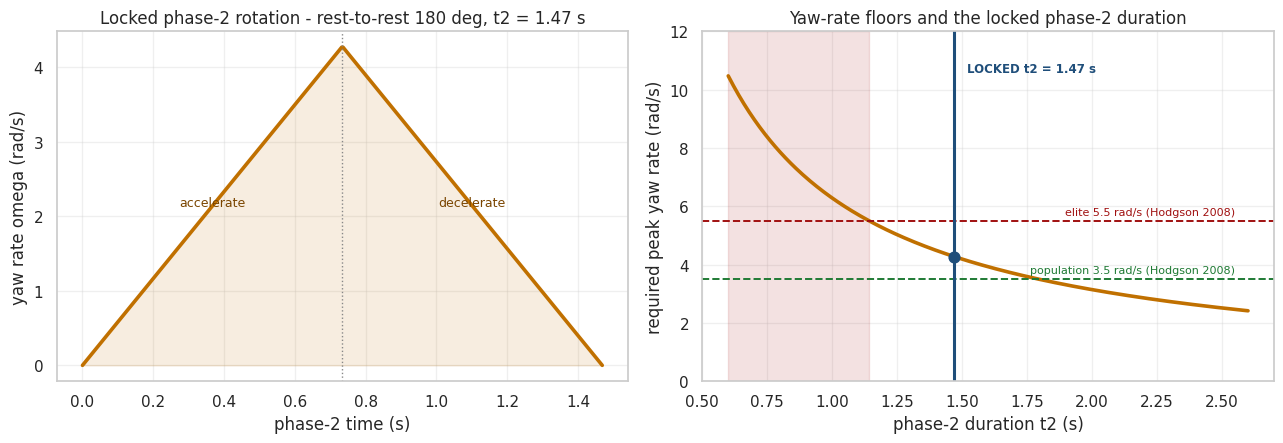

In [5]:
# Phase-2 duration constraint from the 180 deg yaw rotation.
# The body is assumed a rigid body with a human yaw moment of inertia.
I_YAW = KINEMATICS["bodies"]["victoria_yaw_inertia_kgm2"]   # 1.4 kg m^2
DTHETA2 = KINEMATICS["phase2_return"]["rotation_rad"]       # pi rad (180 deg)
T_TOTAL = KINEMATICS["total_time_s"]
# Peak yaw rate of a voluntary 180 deg standing pivot (Hodgson, Lewis &
# Drury 2008): mean 3.5 rad/s, SD 1.0. Population = mean; elite = mean + 2 SD.
OMEGA_POPULATION = 3.5
OMEGA_ELITE = 5.5


def omega_peak_rotation(t2, dtheta=DTHETA2):
    """Peak yaw rate of a rest-to-rest rotation of dtheta in time t2.
    Symmetric accelerate-decelerate: dtheta = omega_peak * t2 / 2."""
    return 2.0 * dtheta / t2


# duration floors: omega_peak <= omega_max  ->  t2 >= 2*dtheta/omega_max
t2_floor_population = 2.0 * DTHETA2 / OMEGA_POPULATION
t2_floor_elite = 2.0 * DTHETA2 / OMEGA_ELITE
# LOCK the phase-2 duration at the midpoint of the two floors - the
# lower-bound constraint adopted for the simulation.
t2_lock = 0.5 * (t2_floor_population + t2_floor_elite)
t1_lock = T_TOTAL - t2_lock
KINEMATICS["time"] = {"phase1_duration_s": t1_lock, "phase2_duration_s": t2_lock}

# rotational dynamics at the locked phase-2 duration
omega_lock = omega_peak_rotation(t2_lock)
alpha_lock = 4.0 * DTHETA2 / t2_lock**2
torque_lock = I_YAW * alpha_lock
L_lock = I_YAW * omega_lock
KE_rot = 0.5 * I_YAW * omega_lock**2

console.print(f"Assumed human-body yaw moment of inertia: I = {I_YAW} kg m^2 "
              f"(Plagenhoef et al. 1983, scaled to 70 kg)")
console.print(f"Phase-2 180 deg rotation, rest-to-rest - yaw-rate duration floors "
              f"(Hodgson et al. 2008):")
console.print(f"  population rate {OMEGA_POPULATION} rad/s  ->  t2 >= "
              f"{t2_floor_population:.2f} s")
console.print(f"  elite rate      {OMEGA_ELITE} rad/s  ->  t2 >= "
              f"{t2_floor_elite:.2f} s")
console.print(f"  [bold]LOCKED phase-2 duration  t2 = {t2_lock:.3f} s[/bold] "
              f"(midpoint)  ->  phase-1  t1 = {t1_lock:.3f} s")
console.print(f"  at the lock: yaw rate {omega_lock:.2f} rad/s, accel "
              f"{alpha_lock:.2f} rad/s^2, torque {torque_lock:.1f} N m, "
              f"angular momentum {L_lock:.2f} kg m^2/s, rotational KE "
              f"{KE_rot:.1f} J")
console.print(f"  [yellow]phase 1 carries the same 180 deg turn: the two "
              f"rotations alone consume {2*t2_lock:.2f} s of the {T_TOTAL:.1f} s "
              f"budget at the locked rate ({2*t2_floor_population:.2f} s at the "
              f"population rate) - leaving almost nothing for the translation."
              f"[/yellow]")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
# (a) the rest-to-rest turn at the locked phase-2 duration
tt = np.linspace(0, t2_lock, 400)
omega_t = np.where(tt <= t2_lock / 2, alpha_lock * tt, alpha_lock * (t2_lock - tt))
axes[0].plot(tt, omega_t, color="#c07000", lw=2.6)
axes[0].fill_between(tt, 0, omega_t, color="#c07000", alpha=0.12)
axes[0].axvline(t2_lock / 2, color="#888888", ls=":", lw=1)
axes[0].text(t2_lock * 0.25, omega_lock * 0.5, "accelerate", ha="center",
             fontsize=9, color="#7a4500")
axes[0].text(t2_lock * 0.75, omega_lock * 0.5, "decelerate", ha="center",
             fontsize=9, color="#7a4500")
axes[0].set_xlabel("phase-2 time (s)")
axes[0].set_ylabel("yaw rate omega (rad/s)")
axes[0].set_title(f"Locked phase-2 rotation - rest-to-rest 180 deg, "
                  f"t2 = {t2_lock:.2f} s")
axes[0].grid(True, alpha=0.3)
# (b) required peak yaw rate vs phase-2 duration, with the floors and the lock
t2v = np.linspace(0.6, 2.6, 300)
axes[1].plot(t2v, omega_peak_rotation(t2v), color="#c07000", lw=2.6)
axes[1].axhline(OMEGA_ELITE, color="#a01010", ls="--", lw=1.4)
axes[1].axhline(OMEGA_POPULATION, color="#1f7a34", ls="--", lw=1.4)
axes[1].axvline(t2_lock, color="#1f4e7a", lw=2.2)
axes[1].scatter([t2_lock], [omega_lock], color="#1f4e7a", s=60, zorder=5)
axes[1].axvspan(t2v[0], t2_floor_elite, color="#a01010", alpha=0.12)
axes[1].text(2.55, OMEGA_ELITE + 0.2, "elite 5.5 rad/s (Hodgson 2008)",
             ha="right", fontsize=8, color="#a01010")
axes[1].text(2.55, OMEGA_POPULATION + 0.2, "population 3.5 rad/s (Hodgson 2008)",
             ha="right", fontsize=8, color="#1f7a34")
axes[1].text(t2_lock + 0.05, 10.6, f"LOCKED t2 = {t2_lock:.2f} s",
             fontsize=8.5, color="#1f4e7a", fontweight="bold")
axes[1].set_xlabel("phase-2 duration t2 (s)")
axes[1].set_ylabel("required peak yaw rate (rad/s)")
axes[1].set_title("Yaw-rate floors and the locked phase-2 duration")
axes[1].set_ylim(0, 12)
axes[1].grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "01b-phase2-rotation.png", dpi=140, bbox_inches="tight")
plt.show()

## Curved CoM Path

Victoria's centre of mass does not travel a straight line - the corridor geometry has a diagonal offset and a body rotating 180 deg sweeps its CoM along a curve.  We model the path as a smooth 2D curve (quadratic Bezier) with **arc length 2.0 m** - the distance the CoM actually travels.

Curved path arc length: 2.000 m  (straight-line 1.919 m)

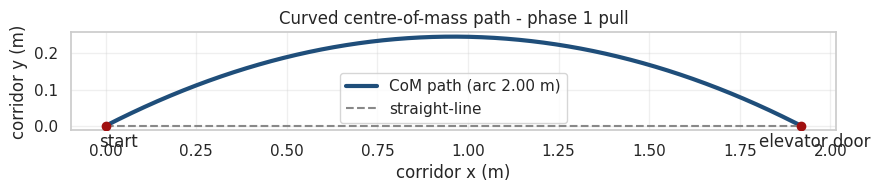

In [6]:
p1 = KINEMATICS["phase1_pull"]
L_arc = p1["path_arc_length_m"]
sag = p1["lateral_offset_m"]

P0 = np.array([0.0, 0.0])
P1 = np.array([1.95, 0.0])
Pc = np.array([0.975, 2.0 * sag])

u = np.linspace(0, 1, 4000)
bez = (1-u)[:, None]**2 * P0 + 2*(1-u)[:, None]*u[:, None] * Pc + u[:, None]**2 * P1
seg = np.sqrt(np.sum(np.diff(bez, axis=0)**2, axis=1))
arc = np.concatenate([[0], np.cumsum(seg)])
scale = L_arc / arc[-1]
bez *= scale
arc *= scale

console.print(f"Curved path arc length: {arc[-1]:.3f} m  "
              f"(straight-line {np.linalg.norm(P1-P0)*scale:.3f} m)")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(bez[:, 0], bez[:, 1], color="#1f4e7a", lw=3, label=f"CoM path (arc {arc[-1]:.2f} m)")
ax.plot([P0[0]*scale, P1[0]*scale], [0, 0], "--", color="#888", label="straight-line")
ax.scatter([P0[0]*scale, P1[0]*scale], [0, 0], color="#a01010", zorder=5)
ax.annotate("start", P0*scale, textcoords="offset points", xytext=(-5, -15))
ax.annotate("elevator door", P1*scale, textcoords="offset points", xytext=(-30, -15))
ax.set_aspect("equal")
ax.set_xlabel("corridor x (m)"); ax.set_ylabel("corridor y (m)")
ax.set_title("Curved centre-of-mass path - phase 1 pull")
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "01b-path-curve.png", dpi=140, bbox_inches="tight")
plt.show()

## Decoupled Trajectory Solver - Two Splines and a Singularity

The choreography and the collision are modelled **separately**.  An impact is not a smooth event - velocity reverses across it almost instantaneously - so folding it into one C2 trajectory would smooth the impact away and leave the collision with no closing velocity.  Instead the model has three pieces:

- **Phase 1 - approach.**  A jerk-minimal cubic-spline acceleration over $[0,\,t_1]$.  It starts at rest and ends at the door, but its terminal velocity $v_\text{close}$ is **left free** - it emerges from the QP as whatever speed is needed to cover the 2 m arc in $t_1$.  The body is released and coasts into the door at $v_\text{close}$.
- **Impact singularity.**  A decoupled impulsive event at $t_1$.  It takes $v_\text{close}$, compresses the body against the rigid door, and returns it to rest.  Resolved on its own millisecond timeline (below); on the 3 s axis it is a **point** - a velocity discontinuity $v_\text{close}\to 0$.
- **Phase 2 - return.**  A second jerk-minimal spline over $[t_1,\,3]$, rest-to-rest, self-propelled, carrying the body 0.5 m back.

Each phase spline solves an equality-constrained **quadratic program** - acceleration is a cubic spline linear in the knot vector $\mathbf a$, and the smoothness cost $\int\dot a^2\,dt=\tfrac12\mathbf a^\top H\mathbf a$ is a quadratic form:

$$\min_{\mathbf a}\ \tfrac12\mathbf a^\top H\mathbf a \quad\text{s.t.}\quad C\mathbf a=\mathbf d$$

solved by the KKT linear system - one solve, no iteration.

**Constraints per phase:**

| Phase | start | end |
|---|---|---|
| 1 - approach | $s=0,\;v=0,\;a=0$ | $s=L_\text{arc},\;a=0$  ($v=v_\text{close}$ free) |
| 2 - return | $s=0,\;v=0,\;a=0$ | $s=-\Delta s_2,\;v=0,\;a=0$ |

Each phase is C2-smooth internally; the velocity step at the singularity is deliberate, not an artefact.

In [7]:
N_KN = KINEMATICS["spline"]["n_knots_per_phase"]
N_EV = KINEMATICS["spline"]["n_eval"]
T = KINEMATICS["total_time_s"]
L_arc = KINEMATICS["phase1_pull"]["path_arc_length_m"]
dS2 = KINEMATICS["phase2_return"]["translation_m"]


def build_phase(duration, n_knots=N_KN, n_eval=N_EV):
    """Jerk-minimal cubic-spline-acceleration QP machinery for one phase.

    a(t) is a cubic spline through n_knots, clamped (jerk = 0) at both ends.
    v = int a and s = int v are analytic antiderivatives with v(0) = s(0) = 0,
    so every kinematic functional is linear in the knot vector and the
    jerk-squared cost is the quadratic form (1/2) a^T H a.
    """
    tk = np.linspace(0.0, duration, n_knots)
    te = np.linspace(0.0, duration, n_eval)
    dte = te[1] - te[0]

    def spline(ak):
        return CubicSpline(tk, ak, bc_type=((1, 0.0), (1, 0.0)))

    def kin(ak):
        ca = spline(ak)
        cv = ca.antiderivative()
        cs = cv.antiderivative()
        return {"t": te, "a": ca(te), "v": cv(te) - cv(0.0),
                "s": cs(te) - cs(0.0) - cv(0.0) * te, "jerk": ca(te, 1),
                "duration": duration}

    def v_at(ak, tt):
        ca = spline(ak); cv = ca.antiderivative()
        return float(cv(tt) - cv(0.0))

    def s_at(ak, tt):
        ca = spline(ak); cv = ca.antiderivative(); cs = cv.antiderivative()
        return float(cs(tt) - cs(0.0) - cv(0.0) * tt)

    def a_at(ak, tt):
        return float(spline(ak)(tt))

    def lin_row(func):
        row = np.zeros(n_knots)
        for i in range(n_knots):
            e = np.zeros(n_knots); e[i] = 1.0
            row[i] = func(e)
        return row

    jb = np.zeros((n_knots, n_eval))
    for i in range(n_knots):
        e = np.zeros(n_knots); e[i] = 1.0
        jb[i] = spline(e)(te, 1)
    Hm = (jb @ jb.T) * dte + 1e-9 * np.eye(n_knots)

    def solve(constraints):
        """constraints: list of (kind, value); kind is 'a0', 'aL', or a
        linear functional func(a_knots) -> float."""
        rows, rhs = [], []
        for kind, val in constraints:
            if kind == "a0":
                r = np.zeros(n_knots); r[0] = 1.0
            elif kind == "aL":
                r = np.zeros(n_knots); r[-1] = 1.0
            else:
                r = lin_row(kind)
            rows.append(r); rhs.append(val)
        C = np.array(rows); d = np.array(rhs)
        nc = C.shape[0]
        KKT = np.block([[Hm, C.T], [C, np.zeros((nc, nc))]])
        sol = np.linalg.solve(KKT, np.concatenate([np.zeros(n_knots), d]))
        return sol[:n_knots]

    return {"solve": solve, "kin": kin, "v_at": v_at, "s_at": s_at,
            "a_at": a_at, "duration": duration}


console.print(f"Phase QP factory ready: {N_KN} knots/phase, clamped cubic "
              f"spline-acceleration, exact KKT solve")

Phase QP factory ready: 31 knots/phase, clamped cubic spline-acceleration, exact KKT solve

In [8]:
def solve_choreography(t1):
    """Solve the two-phase decoupled trajectory for phase-1 duration t1.

    Phase 1: rest -> door, terminal velocity v_close FREE (emergent).
    Phase 2: rest -> 0.5 m back -> rest, self-propelled.
    Returns the per-phase solutions and the emergent closing velocity.
    """
    t2 = T - t1
    # --- phase 1: approach, free terminal velocity ---
    ph1 = build_phase(t1)
    a1 = ph1["solve"]([
        ("a0", 0.0),                              # smooth start, a(0) = 0
        (lambda a: ph1["s_at"](a, t1), L_arc),    # reach the door
        ("aL", 0.0),                              # released, coasting in: a(t1) = 0
    ])
    kin1 = ph1["kin"](a1)
    v_close = ph1["v_at"](a1, t1)                 # EMERGENT closing velocity
    # --- phase 2: return, rest-to-rest ---
    ph2 = build_phase(t2)
    a2 = ph2["solve"]([
        ("a0", 0.0),                              # smooth push-off, a(0) = 0
        (lambda a: ph2["s_at"](a, t2), -dS2),     # 0.5 m back
        (lambda a: ph2["v_at"](a, t2), 0.0),      # end at rest
        ("aL", 0.0),                              # end with a(t2) = 0
    ])
    kin2 = ph2["kin"](a2)
    return {"t1": t1, "t2": t2, "kin1": kin1, "kin2": kin2, "v_close": v_close}


def assemble(s):
    """Stitch phase 1 and phase 2 onto the global 3 s axis. Position is
    continuous; velocity carries the designed singularity step at t1."""
    t1 = s["t1"]
    k1, k2 = s["kin1"], s["kin2"]
    return {
        "t": np.concatenate([k1["t"], k2["t"] + t1]),
        "s": np.concatenate([k1["s"], k2["s"] + L_arc]),  # phase 2 offset to the door
        "v": np.concatenate([k1["v"], k2["v"]]),          # phase-2 v negative (returning)
        "a": np.concatenate([k1["a"], k2["a"]]),
        "jerk": np.concatenate([k1["jerk"], k2["jerk"]]),
        "n1": len(k1["t"]),
    }


t1_opt = float(KINEMATICS["time"]["phase1_duration_s"])
sol = solve_choreography(t1_opt)
traj = assemble(sol)
traj["t_impact"] = t1_opt
v_close = sol["v_close"]

# emergent start ramp: time for |a| to rise to 90% of the phase-1 peak
_a1 = np.abs(sol["kin1"]["a"]); _t1g = sol["kin1"]["t"]
_start_ramp = float(_t1g[np.argmax(_a1 >= 0.9 * _a1.max())])

console.print(f"[bold green]Phase-1 duration (hyperparameter):[/bold green] {t1_opt:.3f} s")
console.print(f"  phase-2 duration             = {sol['t2']:.3f} s")
console.print(f"  [bold]closing velocity v_close   = {v_close:.3f} m/s[/bold]  "
              f"(emergent - phase-1 terminal velocity, free in the QP)")
console.print(f"  phase-1 peak acceleration     = {np.abs(sol['kin1']['a']).max():.3f} m/s^2")
console.print(f"  phase-2 peak acceleration     = {np.abs(sol['kin2']['a']).max():.3f} m/s^2")
console.print(f"  phase-1 peak jerk             = {np.abs(sol['kin1']['jerk']).max():.2f} m/s^3")
console.print(f"  emergent start ramp           = {_start_ramp*1000:.0f} ms (jerk-minimal)")
console.print(f"  singularity at t = {t1_opt:.2f} s: velocity step "
              f"{v_close:.2f} -> 0 m/s (resolved below)")

Phase-1 duration (hyperparameter): 1.531 s

phase-2 duration             = 1.469 s

closing velocity v_close   = 2.452 m/s  (emergent - phase-1 terminal velocity, free in the QP)

phase-1 peak acceleration     = 2.490 m/s^2

phase-2 peak acceleration     = 1.367 m/s^2

phase-1 peak jerk             = 9.67 m/s^3

emergent start ramp           = 432 ms (jerk-minimal)

singularity at t = 1.53 s: velocity step 2.45 -> 0 m/s (resolved below)

## Trajectory - position, velocity, acceleration, jerk

Each phase is C2-smooth.  At the singularity ($t=t_1$) velocity steps discontinuously from $v_\text{close}$ to zero - this is the decoupled impact, not a spline artefact.  Position is continuous across it (the body does not teleport); the few centimetres of body compression belong to the singularity's own millisecond timeline, resolved further down.

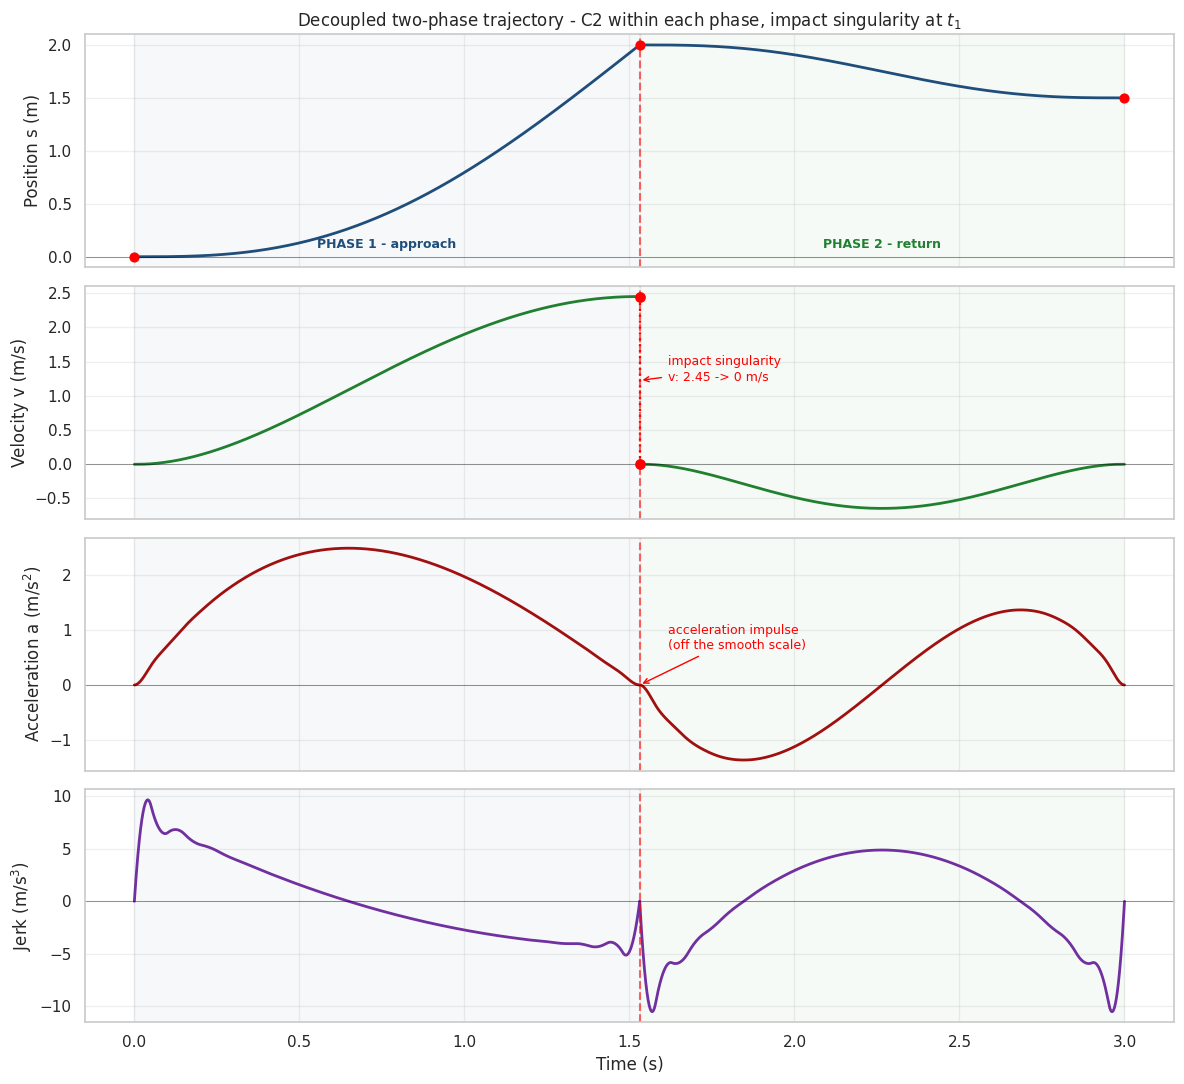

          Decoupled two-phase choreography           
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Quantity                            ┃       Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ Phase 1 (approach) duration         │     1.531 s │
│ Phase 2 (return) duration           │     1.469 s │
│ Closing velocity v_close (emergent) │   2.452 m/s │
│ Phase-1 peak acceleration           │ 2.490 m/s^2 │
│ Phase-2 peak acceleration           │ 1.367 m/s^2 │
│ Phase-1 peak jerk                   │  9.67 m/s^3 │
│ Phase-2 peak jerk                   │ 10.51 m/s^3 │
│ Phase-2 peak return speed           │   0.645 m/s │
└─────────────────────────────────────┴─────────────┘

In [9]:
t = traj["t"]; ti = traj["t_impact"]; n1 = traj["n1"]
fig, axes = plt.subplots(4, 1, figsize=(12, 11), sharex=True)
specs = [
    ("s", "Position s (m)", "#1f4e7a"),
    ("v", "Velocity v (m/s)", "#208030"),
    ("a", "Acceleration a (m/s$^2$)", "#a01010"),
    ("jerk", "Jerk (m/s$^3$)", "#7030a0"),
]
for ax, (key, ylab, col) in zip(axes, specs):
    ax.plot(t[:n1], traj[key][:n1], color=col, lw=2)         # phase 1
    ax.plot(t[n1:], traj[key][n1:], color=col, lw=2)         # phase 2
    ax.axvline(ti, color="red", ls="--", alpha=0.6)
    ax.axhline(0, color="black", lw=0.7, alpha=0.4)
    ax.axvspan(0, ti, color="#1f4e7a", alpha=0.04)
    ax.axvspan(ti, T, color="#208030", alpha=0.04)
    ax.set_ylabel(ylab); ax.grid(True, alpha=0.3)
axes[0].set_title("Decoupled two-phase trajectory - C2 within each phase, "
                  "impact singularity at $t_1$")
axes[0].scatter([0, ti, T], [0, L_arc, L_arc - dS2], color="red", zorder=5, s=40)
# velocity panel: the singularity is an explicit velocity step
axes[1].scatter([ti, ti], [v_close, 0.0], color="red", zorder=5, s=45)
axes[1].plot([ti, ti], [v_close, 0.0], color="red", ls=":", lw=1.6)
axes[1].annotate(f"impact singularity\nv: {v_close:.2f} -> 0 m/s",
                 xy=(ti, v_close * 0.5), textcoords="offset points", xytext=(20, 0),
                 arrowprops=dict(arrowstyle="->", color="red"), fontsize=9, color="red")
axes[2].annotate("acceleration impulse\n(off the smooth scale)", xy=(ti, 0),
                 textcoords="offset points", xytext=(20, 26),
                 arrowprops=dict(arrowstyle="->", color="red"), fontsize=9, color="red")
axes[0].text(ti/2, 0.04*L_arc, "PHASE 1 - approach", ha="center", fontsize=9,
             color="#1f4e7a", fontweight="bold")
axes[0].text((ti+T)/2, 0.04*L_arc, "PHASE 2 - return", ha="center", fontsize=9,
             color="#208030", fontweight="bold")
axes[3].set_xlabel("Time (s)")
fig.tight_layout()
fig.savefig(FIG_DIR / "01b-trajectory-splines.png", dpi=140, bbox_inches="tight")
plt.show()

summary = Table(title="[bold]Decoupled two-phase choreography[/bold]",
                show_header=True, header_style="bold cyan")
summary.add_column("Quantity"); summary.add_column("Value", justify="right")
summary.add_row("Phase 1 (approach) duration", f"{ti:.3f} s")
summary.add_row("Phase 2 (return) duration", f"{T-ti:.3f} s")
summary.add_row("Closing velocity v_close (emergent)",
                f"[bold green]{v_close:.3f} m/s[/bold green]")
summary.add_row("Phase-1 peak acceleration", f"{np.abs(sol['kin1']['a']).max():.3f} m/s^2")
summary.add_row("Phase-2 peak acceleration", f"{np.abs(sol['kin2']['a']).max():.3f} m/s^2")
summary.add_row("Phase-1 peak jerk", f"{np.abs(sol['kin1']['jerk']).max():.2f} m/s^3")
summary.add_row("Phase-2 peak jerk", f"{np.abs(sol['kin2']['jerk']).max():.2f} m/s^3")
summary.add_row("Phase-2 peak return speed", f"{np.abs(sol['kin2']['v']).max():.3f} m/s")
console.print(summary)

## Continuity Verification

Each phase is C4 by construction (cubic-spline acceleration integrated twice) - verified below within phase 1 and within phase 2 separately.  Across the singularity the trajectory is **deliberately discontinuous in velocity**: that step, of size $v_\text{close}$, is the decoupled impact.  Position stays continuous.

        Continuity check - within each phase        
┏━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Phase   ┃ Quantity     ┃ Max |step| ┃ Status     ┃
┡━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ phase 1 │ position     │  9.390e-04 │ continuous │
│ phase 1 │ velocity     │  9.534e-04 │ continuous │
│ phase 1 │ acceleration │  3.701e-03 │ continuous │
│ phase 1 │ jerk         │  1.814e-01 │ continuous │
│ phase 2 │ position     │  2.369e-04 │ continuous │
│ phase 2 │ velocity     │  5.019e-04 │ continuous │
│ phase 2 │ acceleration │  3.861e-03 │ continuous │
│ phase 2 │ jerk         │  2.038e-01 │ continuous │
└─────────┴──────────────┴────────────┴────────────┘

Across the singularity at t=1.53s: velocity step = 2.452 m/s - the decoupled impact, by design.

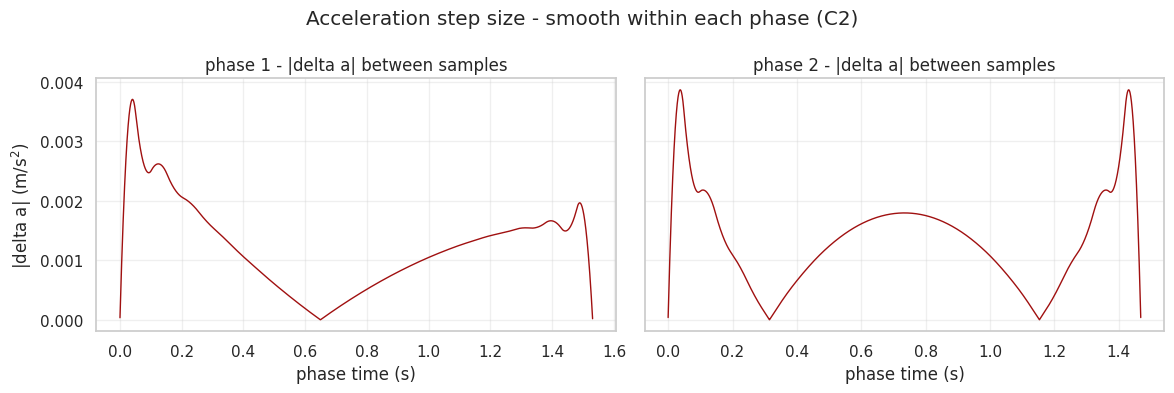

In [10]:
checks = Table(title="[bold]Continuity check - within each phase[/bold]",
               show_header=True, header_style="bold cyan")
checks.add_column("Phase"); checks.add_column("Quantity")
checks.add_column("Max |step|", justify="right"); checks.add_column("Status")
for phase_label, kin in [("phase 1", sol["kin1"]), ("phase 2", sol["kin2"])]:
    for key, label in [("s", "position"), ("v", "velocity"),
                       ("a", "acceleration"), ("jerk", "jerk")]:
        step = np.abs(np.diff(kin[key]))
        # range-relative bound: a continuous finely-sampled signal has
        # max adjacent step << signal range; a real jump is O(range).
        bound = max(0.05 * float(np.ptp(kin[key])), 1e-9)
        mx = step.max()
        checks.add_row(phase_label, label, f"{mx:.3e}",
                       "[green]continuous[/]" if mx < bound else "[red]JUMP[/]")
console.print(checks)
console.print(f"[yellow]Across the singularity at t={ti:.2f}s: velocity step = "
              f"{v_close:.3f} m/s - the decoupled impact, by design.[/yellow]")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (lbl, kin) in zip(axes, [("phase 1", sol["kin1"]), ("phase 2", sol["kin2"])]):
    ax.plot(kin["t"][:-1], np.abs(np.diff(kin["a"])), color="#a01010", lw=1)
    ax.set_xlabel("phase time (s)"); ax.set_title(f"{lbl} - |delta a| between samples")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("|delta a| (m/s$^2$)")
fig.suptitle("Acceleration step size - smooth within each phase (C2)")
fig.tight_layout()
fig.savefig(FIG_DIR / "01b-continuity-check.png", dpi=140, bbox_inches="tight")
plt.show()

## Impact Singularity - Resolving the Collision

The singularity at $t_1$ is now resolved on its own timeline.  The body reaches the rigid door at the emergent closing velocity $v_\text{close}$ and is brought to rest over its compression distance $d$.  This is a separate impulsive event - decoupled from the choreography splines.

The peak deceleration depends on the yield shape.  Constant deceleration ($a=v_\text{close}^2/2d$) is the lowest-peak case; realistic elastic and Hertzian bodies peak higher for the same compression and closing speed.  The impact **duration** $\tau_\text{imp}\approx 2d/v_\text{close}$ confirms the decoupling: a few tens of milliseconds against a 3 s choreography, so on the choreography axis the event is genuinely a point.

The total force at the impact combines this impact-force component with Victoria's own acceleration force (push off the door and feet) - their split is the `accel_force_fraction` hyperparameter, applied downstream.

Impact singularity input: v_close = 2.452 m/s (emergent phase-1 terminal velocity)

kinetic energy at contact = 210 J,  impulse m*v_close = 172 N*s

              Impact singularity - body compression 3 cm, v_close=2.45 m/s              
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Yield model              ┃ a_peak (m/s2) ┃ a_peak (g) ┃ F_impact (kN) ┃ tau_imp (ms) ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ constant (rigid-plastic) │           100 │       10.2 │          7.02 │           24 │
│ half-sine                │           157 │       16.0 │         11.02 │           24 │
│ smootherstep             │           188 │       19.2 │         13.19 │           24 │
│ linear elastic spring    │           200 │       20.4 │         14.03 │           24 │
│ Hertzian (n=1.5)         │           251 │       25.6 │         17.54 │           24 │
└──────────────────────────┴───────────────┴────────────┴───────────────┴──────────────┘

tau_imp ~ 24 ms << 3000 ms choreography - the impact is a point on the 3 s axis, i.e. a genuine singularity.

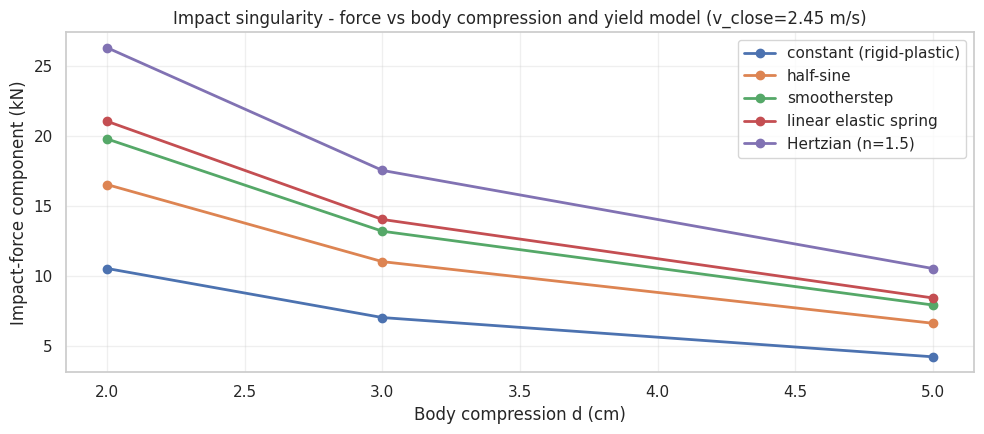

In [11]:
m_v = KINEMATICS["bodies"]["victoria_mass_kg"]
console.print(f"Impact singularity input: v_close = {v_close:.3f} m/s "
              f"(emergent phase-1 terminal velocity)")
console.print(f"  kinetic energy at contact = {0.5*m_v*v_close**2:.0f} J,  "
              f"impulse m*v_close = {m_v*v_close:.0f} N*s")

# yield-shape peak factor: a_peak = factor * v_close^2 / d
yield_factor = {"constant (rigid-plastic)": 0.50, "half-sine": 0.785,
                "smootherstep": 0.94, "linear elastic spring": 1.00,
                "Hertzian (n=1.5)": 1.25}
rows = []
for model, fac in yield_factor.items():
    for d_cm in [2.0, 3.0, 5.0]:
        d = d_cm / 100.0
        a_pk = fac * v_close**2 / d
        tau = 2.0 * d / v_close          # ~ contact duration, mean-speed estimate
        rows.append((model, d_cm, a_pk, a_pk/9.80665, m_v*a_pk/1000, tau*1000))
ydf = pd.DataFrame(rows, columns=["model", "d_cm", "a_peak", "a_peak_g",
                                  "F_kN", "tau_ms"])

ytab = Table(title=f"[bold]Impact singularity - body compression 3 cm, "
             f"v_close={v_close:.2f} m/s[/bold]",
             show_header=True, header_style="bold cyan")
for col in ("Yield model", "a_peak (m/s2)", "a_peak (g)", "F_impact (kN)",
            "tau_imp (ms)"):
    ytab.add_column(col, justify="right" if col != "Yield model" else "left")
for _, r in ydf[ydf.d_cm == 3.0].iterrows():
    ytab.add_row(r.model, f"{r.a_peak:.0f}", f"{r.a_peak_g:.1f}", f"{r.F_kN:.2f}",
                 f"{r.tau_ms:.0f}")
console.print(ytab)
_tau3 = ydf[ydf.d_cm == 3.0].tau_ms.iloc[0]
console.print(f"[yellow]tau_imp ~ {_tau3:.0f} ms << 3000 ms choreography - the "
              f"impact is a point on the 3 s axis, i.e. a genuine singularity.[/yellow]")

fig, ax = plt.subplots(figsize=(10, 4.5))
for model in ydf.model.unique():
    sub = ydf[ydf.model == model]
    ax.plot(sub.d_cm, sub.F_kN, "o-", lw=2, label=model)
ax.set_xlabel("Body compression d (cm)"); ax.set_ylabel("Impact-force component (kN)")
ax.set_title(f"Impact singularity - force vs body compression and yield model "
             f"(v_close={v_close:.2f} m/s)")
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "01b-yield-study.png", dpi=140, bbox_inches="tight")
plt.show()

## Phase Split - Why Phase 2 Cannot Be Short

The 3 s budget divides into phase 1 (the pull to the elevator door) and phase 2 (everything after the impact).  These two phases are not choreographically equal.

**Phase 1** is a single translation: Victoria's centre of mass is moved along the 2 m curved path, with a co-rotation.  One sustained action.

**Phase 2** is choreographically dense, and its end-state is **fixed by witness testimony**.  The court social curator, Cecilia, testified (`references/incident/testimony_3rd_party.md`) that she was asked to step aside, took three steps and briefly turned away, and on turning back observed Victoria leaning against Andrew **front-first** with Andrew's hands raised, after which Victoria slid down the door front-first and crawled forward.  Her account places the entire alleged impact within the window of her averted gaze.

Phase 2 therefore is not free - it must carry Victoria from the impact configuration the accusation requires (back-first against the elevator door) to the configuration Cecilia actually reported (front-first against Andrew).  Within phase 2 Victoria must, in sequence:

1. accelerate away from the elevator door (she has just been driven into it back-first and must now move back),
2. decelerate to a controlled stop,
3. complete a **180 deg rotation** - back-first at the door to front-first against Andrew, the orientation reversal Cecilia's testimony demands,
4. arrive precisely in the leaning / "hug" configuration Cecilia described, in time for her to see it on turning back.

Four distinct sub-actions, each with its own acceleration and deceleration, plus a full half-rotation, all chained into one smooth motion and all ending in the specific body configuration a third-party witness has placed on the record.

This makes the phase split consequential.  Giving phase 1 the larger share starves the dense, testimony-constrained phase 2:

- **phase 1 = 2.0 s -> phase 2 = 1.0 s**: one second to accelerate, decelerate, rotate 180 deg, and reach the configuration Cecilia described - implausibly compressed.
- **phase 1 = 1.5 s -> phase 2 = 1.5 s**: still tight.  1.5 s for accelerate + decelerate + half-rotation + final positioning is **not generous**.
- **phase 1 = 1.0 s -> phase 2 = 2.0 s**: phase 2 finally has room, but phase 1 now compresses the 2 m curved pull into 1 s, driving its peak velocity and acceleration up sharply.

There is no comfortable split.  The curves below model all three.

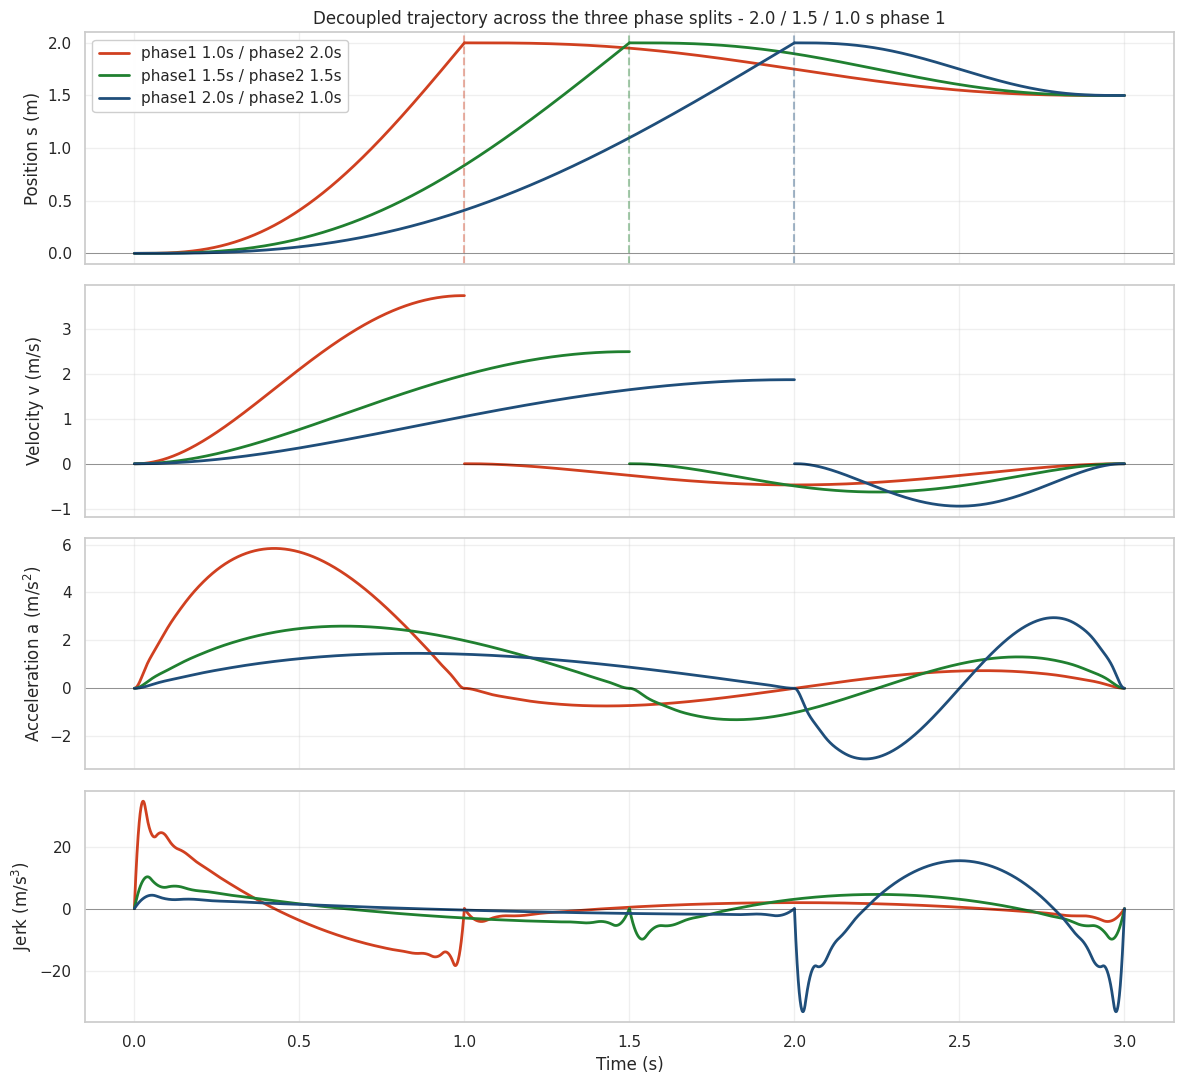

                                     Phase-split comparison - decoupled model                                      
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃             ┃             ┃               ┃      ph1 peak a ┃      ph2 peak a ┃               ┃    return speed ┃
┃ phase 1 (s) ┃ phase 2 (s) ┃ v_close (m/s) ┃          (m/s2) ┃          (m/s2) ┃ ph1 peak jerk ┃           (m/s) ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│         1.0 │         2.0 │          3.75 │            5.84 │            0.74 │          34.7 │            0.47 │
│         1.5 │         1.5 │          2.50 │            2.59 │            1.31 │          10.3 │            0.63 │
│         2.0 │         1.0 │          1.88 │            1.46 │            2.95 │           4.3 │            0.95 │
└─────────────┴─────────────┴───────────────┴─────────────────┴─────────────────┴───────────────┴─────────────────┘

Shorter phase 1 raises the closing velocity v_close the impact singularity must absorb; longer phase 1 starves the 
testimony-constrained phase 2.

In [12]:
# Phase-split comparison: phase-1 duration t1 = 1.0, 1.5, 2.0 s
split_times = [1.0, 1.5, 2.0]
split_colors = {1.0: "#d04020", 1.5: "#208030", 2.0: "#1f4e7a"}
split_sol = {t1: solve_choreography(t1) for t1 in split_times}
split_traj = {t1: assemble(split_sol[t1]) for t1 in split_times}

fig, axes = plt.subplots(4, 1, figsize=(12, 11), sharex=True)
specs = [("s", "Position s (m)"), ("v", "Velocity v (m/s)"),
         ("a", "Acceleration a (m/s$^2$)"), ("jerk", "Jerk (m/s$^3$)")]
for t1 in split_times:
    tr = split_traj[t1]; nn = tr["n1"]
    for ax, (key, _) in zip(axes, specs):
        ax.plot(tr["t"][:nn], tr[key][:nn], color=split_colors[t1], lw=2,
                label=f"phase1 {t1:.1f}s / phase2 {3-t1:.1f}s")
        ax.plot(tr["t"][nn:], tr[key][nn:], color=split_colors[t1], lw=2)
for ax, (_, ylab) in zip(axes, specs):
    ax.axhline(0, color="black", lw=0.7, alpha=0.4)
    ax.set_ylabel(ylab); ax.grid(True, alpha=0.3)
for t1 in split_times:
    axes[0].axvline(t1, color=split_colors[t1], ls="--", alpha=0.4)
axes[0].set_title("Decoupled trajectory across the three phase splits - "
                  "2.0 / 1.5 / 1.0 s phase 1")
axes[0].legend(loc="upper left", framealpha=0.95)
axes[3].set_xlabel("Time (s)")
fig.tight_layout()
fig.savefig(FIG_DIR / "01b-phase-split-comparison.png", dpi=140, bbox_inches="tight")
plt.show()

cmp = Table(title="[bold]Phase-split comparison - decoupled model[/bold]",
            show_header=True, header_style="bold cyan")
for col in ("phase 1 (s)", "phase 2 (s)", "v_close (m/s)", "ph1 peak a (m/s2)",
            "ph2 peak a (m/s2)", "ph1 peak jerk", "return speed (m/s)"):
    cmp.add_column(col, justify="right")
for t1 in split_times:
    s_ = split_sol[t1]
    cmp.add_row(f"{t1:.1f}", f"{3-t1:.1f}", f"{s_['v_close']:.2f}",
                f"{np.abs(s_['kin1']['a']).max():.2f}",
                f"{np.abs(s_['kin2']['a']).max():.2f}",
                f"{np.abs(s_['kin1']['jerk']).max():.1f}",
                f"{np.abs(s_['kin2']['v']).max():.2f}")
console.print(cmp)
console.print("[yellow]Shorter phase 1 raises the closing velocity v_close the "
              "impact singularity must absorb; longer phase 1 starves the "
              "testimony-constrained phase 2.[/yellow]")

## Exclusion Zones - Literature Bounds on the Solution Manifold

The QP returns the choreography that is *kinematically* smoothest for a given phase split.  Whether a human body can actually **produce** it is a separate question - and literature answers it.

Each derived parameter has a permissible band from biomechanics literature, of two kinds.  **Production limits** are what the body can generate - peak acceleration, peak jerk, the rate at which propulsive force can be ramped, peak yaw rate.  A required value beyond a production limit is an **exclusion zone**: the motion is not merely hard, it is impossible.  **Tolerance limits** - the impact deceleration - are what the body can withstand, applied downstream.

The solution manifold is parametrised by the one free hyperparameter, the phase split $t_1$ (with $t_2=3-t_1$).  Sweeping $t_1$, every derived parameter traces a curve, and each literature band cuts that curve into admissible and excluded intervals.  The body must satisfy all of them at once, so the feasible manifold is the **intersection**.

With the phase-2 rotation included, the manifold now has **both jaws of the pincer**: short $t_1$ is excluded by the translational acceleration of phase 1, long $t_1$ by the yaw rate of the phase-2 rotation.  The admissible window is whatever survives between them.

| Parameter | Permissible band | Type | Reference |
|---|---|---|---|
| $a_\text{max}$ - phase-1 peak acceleration | $\le 5.5$ m/s$^2$ (elite mean +1 SD); 3.0 typical | production | Mero, Komi & Gregor 1992 |
| $j_\text{peak}$ - peak jerk | $\le \sim 50$ m/s$^3$ (order-of-magnitude) | production | RFD-derived: Maffiuletti et al. 2016, Aagaard et al. 2002 |
| $\tau_\text{give}$ - start-ramp duration | $\ge 0.12$ s - propulsive force cannot ramp faster | production | Maffiuletti et al. 2016; Aagaard et al. 2002 |
| $\omega_\text{peak}$ - phase-2 yaw rate | $\le 5.5$ rad/s (mean +2 SD); 3.5 typical | production | Hodgson, Lewis & Drury 2008 |
| $v_\text{close}$ - closing velocity | a kinematic outcome - no direct production ceiling | - | - |

The bands above use the generous ceilings (elite, mean + SD) - the charitable reading.  At the typical population values the window is far narrower, and phase 1's identical 180 degree rotation, not drawn here, would close it further.

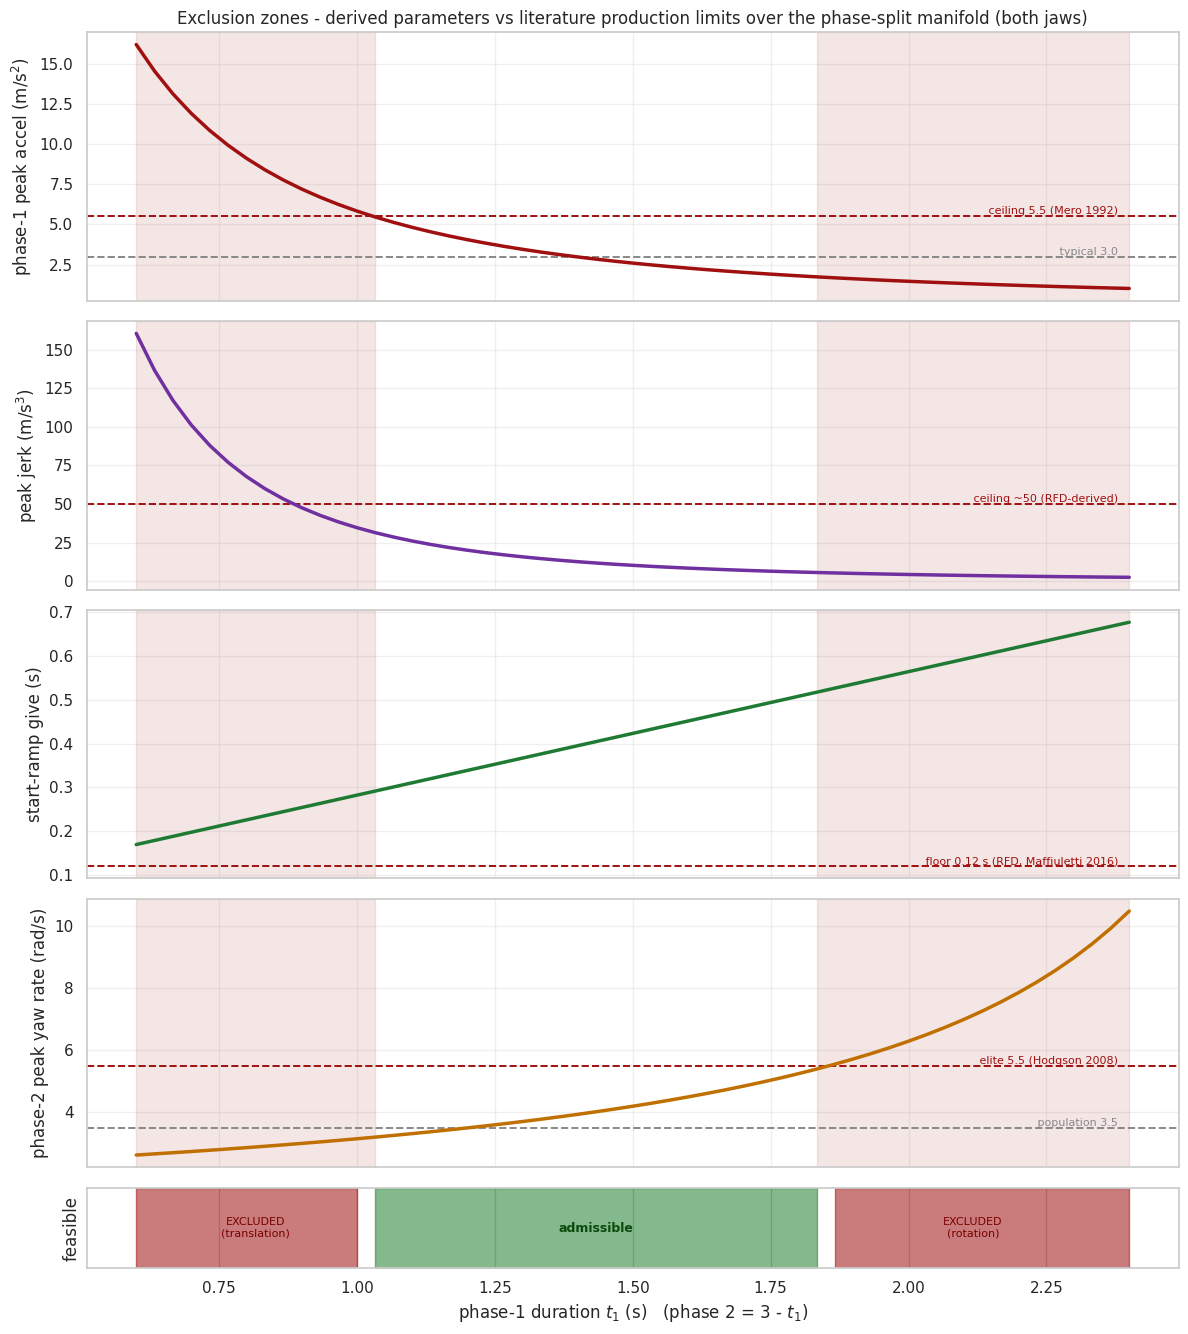

              Derived parameters vs literature production limits (phase-1 = 1.5 s, phase-2 = 1.5 s)               
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Parameter          ┃ QP value ┃      Literature band ┃ Reference                                     ┃ Verdict ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ a_max (m/s2)       │     2.49 │ <= 5.5 (3.0 typical) │ Mero, Komi & Gregor (1992)                    │  within │
│ j_peak (m/s3)      │      9.7 │               <= ~50 │ Maffiuletti 2016 / Aagaard 2002 (RFD-derived) │  within │
│ tau_give (s)       │    0.432 │              >= 0.12 │ Maffiuletti 2016; Aagaard 2002                │  within │
│ omega_peak (rad/s) │     4.28 │    <= 5.5 (3.5 pop.) │ Hodgson, Lewis & Drury (2008)                 │  within │
│ v_close (m/s)      │     2.45 │    no direct ceiling │ binds via a_max                               │       - │
└────────────────────┴──────────┴──────────────────────┴───────────────────────────────────────────────┴─────────┘

Translational limits exclude t1 < 1.03 s (peak acceleration); the phase-2 rotation excludes t1 > 1.83 s (yaw rate).
The admissible window is t1 in [1.03, 1.83] s, 0.80 s wide - and only at the generous ceilings. At the typical 
population rates, and with phase 1's own 180 deg rotation, it narrows further.

In [13]:
# Literature production limits on the derived parameters.
A_MAX_TYPICAL = 3.0      # Mero 1992 - recreational peak CoM acceleration (m/s^2)
A_MAX_CEILING = 5.5      # Mero 1992 - elite mean 5.0 + ~1 SD (m/s^2)
TAU_GIVE_FLOOR = 0.12    # RFD - explosive force needs ~100-150 ms minimum (s)
J_PEAK_CEILING = 50.0    # order-of-magnitude: a_max,ceiling / tau_give,floor
# OMEGA_ELITE / OMEGA_POPULATION / omega_peak_rotation: from the
# Phase-2 Duration Constraint section above.

LIT_REF = {
    "a_max": "Mero, Komi & Gregor (1992)",
    "j_peak": "Maffiuletti 2016 / Aagaard 2002 (RFD-derived)",
    "tau_give": "Maffiuletti 2016; Aagaard 2002",
    "omega": "Hodgson, Lewis & Drury (2008)",
}


def phase1_metrics(t1):
    """Phase-1 derived parameters for the exclusion-zone sweep."""
    sc = solve_choreography(t1)
    k1 = sc["kin1"]
    a = np.abs(k1["a"]); a_pk = a.max()
    tau_give = float(k1["t"][np.argmax(a >= 0.9 * a_pk)])
    return {"a_max": a_pk, "j_peak": float(np.abs(k1["jerk"]).max()),
            "tau_give": tau_give, "v_close": sc["v_close"]}


# sweep the one free hyperparameter - the phase split t1 (t2 = T - t1)
t1_sweep = np.linspace(0.6, 2.4, 55)
m1 = [phase1_metrics(t1) for t1 in t1_sweep]
a_max_c = np.array([m["a_max"] for m in m1])
j_peak_c = np.array([m["j_peak"] for m in m1])
tau_c = np.array([m["tau_give"] for m in m1])
omega_c = omega_peak_rotation(T - t1_sweep)

# excluded where any production limit is violated
excl = ((a_max_c > A_MAX_CEILING) | (j_peak_c > J_PEAK_CEILING) |
        (tau_c < TAU_GIVE_FLOOR) | (omega_c > OMEGA_ELITE))
feas = t1_sweep[~excl]
t1_feas_min = float(feas.min()) if feas.size else float("nan")
t1_feas_max = float(feas.max()) if feas.size else float("nan")

fig, axes = plt.subplots(5, 1, figsize=(12, 13.5), sharex=True,
                         gridspec_kw={"height_ratios": [1, 1, 1, 1, 0.3]})
panels = [
    (axes[0], a_max_c, "phase-1 peak accel (m/s$^2$)", "#a01010",
     [(A_MAX_CEILING, "ceiling 5.5 (Mero 1992)", "#a01010"),
      (A_MAX_TYPICAL, "typical 3.0", "#888888")]),
    (axes[1], j_peak_c, "peak jerk (m/s$^3$)", "#7030a0",
     [(J_PEAK_CEILING, "ceiling ~50 (RFD-derived)", "#a01010")]),
    (axes[2], tau_c, "start-ramp give (s)", "#1f7a34",
     [(TAU_GIVE_FLOOR, "floor 0.12 s (RFD, Maffiuletti 2016)", "#a01010")]),
    (axes[3], omega_c, "phase-2 peak yaw rate (rad/s)", "#c07000",
     [(OMEGA_ELITE, "elite 5.5 (Hodgson 2008)", "#a01010"),
      (OMEGA_POPULATION, "population 3.5", "#888888")]),
]
for ax, curve, ylab, col, lines in panels:
    ax.plot(t1_sweep, curve, color=col, lw=2.5, zorder=4)
    for lvl, lab, lc in lines:
        ax.axhline(lvl, color=lc, ls="--", lw=1.4)
        ax.text(2.38, lvl, " " + lab, ha="right", va="bottom", fontsize=8, color=lc)
    if np.isfinite(t1_feas_min):
        ax.axvspan(t1_sweep[0], t1_feas_min, color="#a01010", alpha=0.10)
        ax.axvspan(t1_feas_max, t1_sweep[-1], color="#a01010", alpha=0.10)
    ax.set_ylabel(ylab); ax.grid(True, alpha=0.3)
axes[0].set_title("Exclusion zones - derived parameters vs literature "
                  "production limits over the phase-split manifold (both jaws)")
# feasibility strip
axf = axes[4]
axf.fill_between(t1_sweep, 0, 1, where=~excl, color="#208030", alpha=0.55, step="mid")
axf.fill_between(t1_sweep, 0, 1, where=excl, color="#a01010", alpha=0.55, step="mid")
axf.set_yticks([]); axf.set_ylim(0, 1); axf.set_ylabel("feasible")
axf.set_xlabel("phase-1 duration $t_1$ (s)   (phase 2 = 3 - $t_1$)")
if np.isfinite(t1_feas_min):
    axf.text((t1_feas_min + t1_feas_max) / 2, 0.5, "admissible", ha="center",
             va="center", fontsize=9, color="#0a4a0a", fontweight="bold")
    axf.text((t1_sweep[0] + t1_feas_min) / 2, 0.5, "EXCLUDED\n(translation)",
             ha="center", va="center", fontsize=8, color="#7a0000")
    axf.text((t1_feas_max + t1_sweep[-1]) / 2, 0.5, "EXCLUDED\n(rotation)",
             ha="center", va="center", fontsize=8, color="#7a0000")
fig.tight_layout()
fig.savefig(FIG_DIR / "01b-exclusion-zones.png", dpi=140, bbox_inches="tight")
plt.show()

# verdict table at the chosen phase split
mref = phase1_metrics(t1_opt)
omref = omega_peak_rotation(T - t1_opt)
vt = Table(title=f"[bold]Derived parameters vs literature production limits "
           f"(phase-1 = {t1_opt:.1f} s, phase-2 = {T-t1_opt:.1f} s)[/bold]",
           show_header=True, header_style="bold cyan")
for c_ in ("Parameter", "QP value", "Literature band", "Reference", "Verdict"):
    vt.add_column(c_, justify="left" if c_ in ("Parameter", "Reference") else "right")
def _verdict(ok):
    return "[green]within[/]" if ok else "[red]EXCLUDED[/]"
vt.add_row("a_max (m/s2)", f"{mref['a_max']:.2f}", "<= 5.5 (3.0 typical)",
           LIT_REF["a_max"], _verdict(mref["a_max"] <= A_MAX_CEILING))
vt.add_row("j_peak (m/s3)", f"{mref['j_peak']:.1f}", "<= ~50",
           LIT_REF["j_peak"], _verdict(mref["j_peak"] <= J_PEAK_CEILING))
vt.add_row("tau_give (s)", f"{mref['tau_give']:.3f}", ">= 0.12",
           LIT_REF["tau_give"], _verdict(mref["tau_give"] >= TAU_GIVE_FLOOR))
vt.add_row("omega_peak (rad/s)", f"{omref:.2f}", "<= 5.5 (3.5 pop.)",
           LIT_REF["omega"], _verdict(omref <= OMEGA_ELITE))
vt.add_row("v_close (m/s)", f"{mref['v_close']:.2f}", "no direct ceiling",
           "binds via a_max", "[dim]-[/]")
console.print(vt)
console.print(f"[yellow]Translational limits exclude t1 < {t1_feas_min:.2f} s "
              f"(peak acceleration); the phase-2 rotation excludes "
              f"t1 > {t1_feas_max:.2f} s (yaw rate). The admissible window is "
              f"t1 in [{t1_feas_min:.2f}, {t1_feas_max:.2f}] s, "
              f"{t1_feas_max-t1_feas_min:.2f} s wide - and only at the generous "
              f"ceilings. At the typical population rates, and with phase 1's "
              f"own 180 deg rotation, it narrows further.[/yellow]")

## Summary

- The choreography and the collision are modelled **separately**.  Two jerk-minimal cubic-spline trajectories - phase 1 (approach) and phase 2 (return) - each solved as a quadratic program (jerk-squared minimised, exact KKT solve), with the impact handled as a **decoupled singularity** between them.
- **Phase 1** starts at rest and ends at the door with a **free terminal velocity** $v_\text{close}$ - the closing speed emerges from the QP as whatever covers the 2.0 m curved path in the phase-1 time, rather than being forced to zero.
- The **impact singularity** is a separate impulsive event: it takes $v_\text{close}$, compresses the body against the rigid door, and returns it to rest over a few tens of milliseconds.  On the 3 s choreography axis it is a point - a velocity discontinuity, not a smooth turning point.
- **Phase 2** is a rest-to-rest, self-propelled return - Victoria pushing off the door and floor to carry her centre of mass 0.5 m back.
- Each phase is C2-smooth internally (verified); the velocity step at the singularity is deliberate.  This fixes the earlier model, where a single C2 trajectory through $v=a=0$ at the door smoothed the impact away and left the collision with no closing velocity.
- **Forces are downstream.**  The total force at the impact combines the impact-force component (the singularity, tabulated above) with Victoria's own acceleration force; their proportion is the `accel_force_fraction` hyperparameter.
- **Biomechanical feasibility is a literature question, not a QP output.**  Each derived parameter is checked against a permissible band from biomechanics literature; required values beyond a production limit form **exclusion zones** in the solution manifold.  The translational limits exclude short phase-1 durations; the **phase-2 180 degree yaw rotation** - a rest-to-rest turn whose peak rate is capped by Hodgson et al. 2008 - excludes long phase-1 durations.  The phase-2 duration is **locked** at the midpoint of the elite and population yaw-rate floors (~1.47 s) as the lower-bound constraint.  Both jaws of the pincer close on a narrow admissible window.